In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn for processing and standard models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Gradient Boosting Libraries
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# 1. Load Data
df = pd.read_csv('Concrete_Data_Yeh.csv')

# 2. Check Data
print(f"Dataset Shape: {df.shape}")
print(df.head())

# 3. Split Data
X = df.drop('csMPa', axis=1)
y = df['csMPa']

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale Data (Important for SVM and Neural Nets, helpful for others)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData Preprocessing Complete.")

Dataset Shape: (1030, 9)
   cement   slag  flyash  water  superplasticizer  coarseaggregate  \
0   540.0    0.0     0.0  162.0               2.5           1040.0   
1   540.0    0.0     0.0  162.0               2.5           1055.0   
2   332.5  142.5     0.0  228.0               0.0            932.0   
3   332.5  142.5     0.0  228.0               0.0            932.0   
4   198.6  132.4     0.0  192.0               0.0            978.4   

   fineaggregate  age  csMPa  
0          676.0   28  79.99  
1          676.0   28  61.89  
2          594.0  270  40.27  
3          594.0  365  41.05  
4          825.5  360  44.30  

Data Preprocessing Complete.


In [3]:
# Initialize Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbose=-1),
    "SVM": SVR(kernel='rbf')
}

# Dictionary to store results
results = []
trained_models = {}

print("Training Models...")

# Train and Predict Loop
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    trained_models[name] = model
    
    print(f"{name} -> R2: {r2:.4f}")

# Create Comparison DataFrame
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\nFinal Leaderboard:")
print(results_df)

Training Models...
Random Forest -> R2: 0.8814
CatBoost -> R2: 0.9367
XGBoost -> R2: 0.9111
LightGBM -> R2: 0.9188
SVM -> R2: 0.6548

Final Leaderboard:
           Model       MAE      RMSE        R2
1       CatBoost  2.634508  4.038893  0.936693
3       LightGBM  3.016426  4.575548  0.918752
2        XGBoost  3.082463  4.785049  0.911142
0  Random Forest  3.784443  5.528439  0.881388
4            SVM  7.514947  9.431830  0.654764


c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


C:\Users\victo\AppData\Local\Temp\ipykernel_15552\3730781369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')


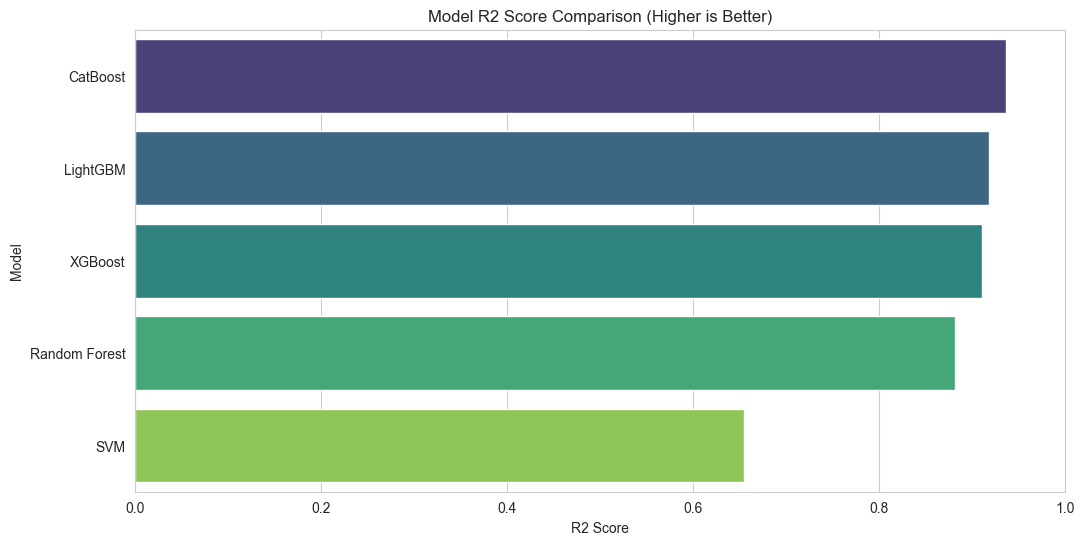

Top 2 Performing Models: ['CatBoost', 'LightGBM']


c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


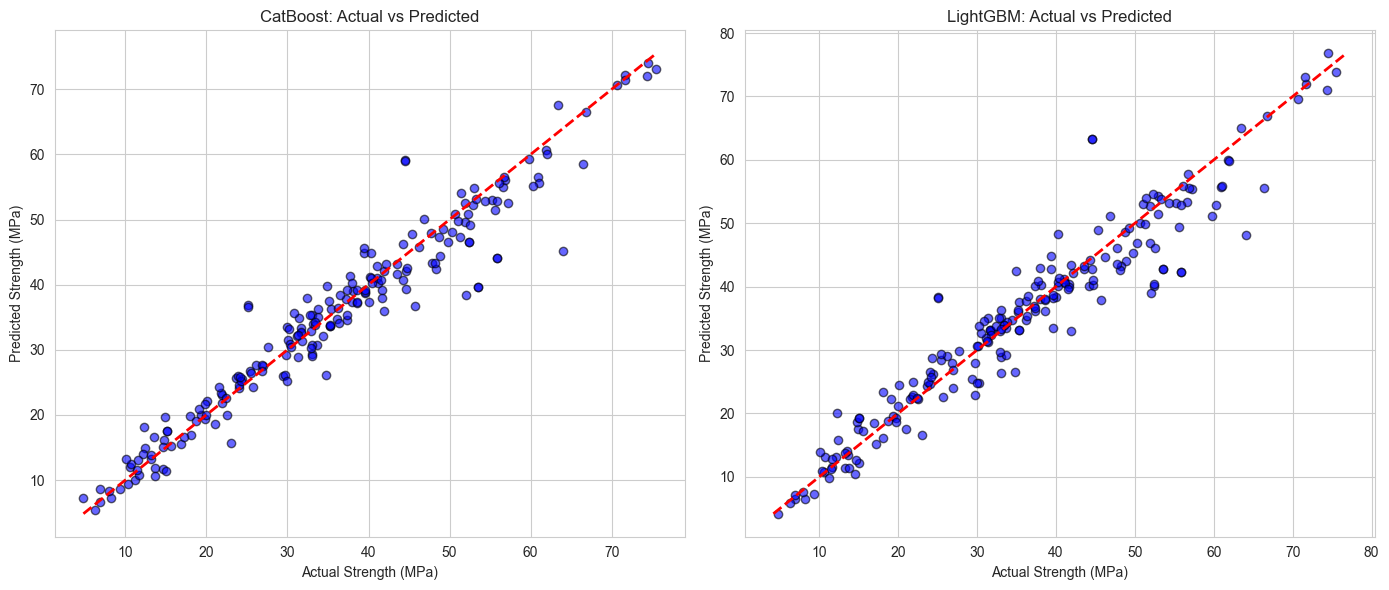

In [4]:
# 1. Bar Chart of R2 Score
plt.figure(figsize=(12, 6))
sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')
plt.title('Model R2 Score Comparison (Higher is Better)')
plt.xlabel('R2 Score')
plt.xlim(0, 1.0)
plt.show()

# 2. Actual vs Predicted Plots for the Top 2 Models
top_2_names = results_df.head(2)['Model'].tolist()
print(f"Top 2 Performing Models: {top_2_names}")

plt.figure(figsize=(14, 6))

for i, model_name in enumerate(top_2_names):
    model = trained_models[model_name]
    y_pred = model.predict(X_test_scaled)
    
    plt.subplot(1, 2, i+1)
    plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolor='k')
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    plt.xlabel('Actual Strength (MPa)')
    plt.ylabel('Predicted Strength (MPa)')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.grid(True)

plt.tight_layout()
plt.show()

[I 2026-01-27 06:45:43,619] A new study created in memory with name: no-name-77c618d2-b815-4d65-ae4f-5de9ad7e4015


Starting Optuna Optimization (This may take a few minutes)...

Optimizing Random Forest...


[I 2026-01-27 06:45:51,949] Trial 0 finished with value: 0.9016219798032331 and parameters: {'n_estimators': 555, 'max_depth': 25, 'min_samples_split': 3}. Best is trial 0 with value: 0.9016219798032331.
[I 2026-01-27 06:45:59,338] Trial 1 finished with value: 0.8853306221505969 and parameters: {'n_estimators': 771, 'max_depth': 16, 'min_samples_split': 10}. Best is trial 0 with value: 0.9016219798032331.
[I 2026-01-27 06:46:05,433] Trial 2 finished with value: 0.8998936756053227 and parameters: {'n_estimators': 480, 'max_depth': 24, 'min_samples_split': 4}. Best is trial 0 with value: 0.9016219798032331.
[I 2026-01-27 06:46:07,614] Trial 3 finished with value: 0.8913798451834275 and parameters: {'n_estimators': 588, 'max_depth': 48, 'min_samples_split': 8}. Best is trial 0 with value: 0.9016219798032331.
[I 2026-01-27 06:46:10,249] Trial 4 finished with value: 0.8853728882811512 and parameters: {'n_estimators': 711, 'max_depth': 37, 'min_samples_split': 10}. Best is trial 0 with value

Best R2 for Random Forest: 0.9034

Optimizing XGBoost...


[I 2026-01-27 06:47:30,348] Trial 0 finished with value: 0.9150387556805089 and parameters: {'n_estimators': 533, 'learning_rate': 0.11917297470133732, 'max_depth': 8, 'subsample': 0.7418724428785348, 'colsample_bytree': 0.7421643111092456}. Best is trial 0 with value: 0.9150387556805089.
[I 2026-01-27 06:47:32,209] Trial 1 finished with value: 0.9030502232769656 and parameters: {'n_estimators': 349, 'learning_rate': 0.19315352206106898, 'max_depth': 10, 'subsample': 0.947925613654056, 'colsample_bytree': 0.8814577992027381}. Best is trial 0 with value: 0.9150387556805089.
[I 2026-01-27 06:47:32,637] Trial 2 finished with value: 0.9181200440697924 and parameters: {'n_estimators': 313, 'learning_rate': 0.07551207725531908, 'max_depth': 3, 'subsample': 0.8860499133156137, 'colsample_bytree': 0.8409106460814991}. Best is trial 2 with value: 0.9181200440697924.
[I 2026-01-27 06:47:32,928] Trial 3 finished with value: 0.9208943479686007 and parameters: {'n_estimators': 419, 'learning_rate':

...

[I 2026-01-27 06:51:43,583] Trial 1 finished with value: 0.8399363730477499 and parameters: {'C': 41.54519765139361, 'epsilon': 0.8119113696122622, 'gamma': 'scale'}. Best is trial 1 with value: 0.8399363730477499.
[I 2026-01-27 06:51:43,687] Trial 2 finished with value: 0.35612755798054296 and parameters: {'C': 0.3250230687623745, 'epsilon': 0.2959850641371798, 'gamma': 'auto'}. Best is trial 1 with value: 0.8399363730477499.
[I 2026-01-27 06:51:43,805] Trial 3 finished with value: 0.6203512249275073 and parameters: {'C': 1.1191381481846228, 'epsilon': 0.521817196210651, 'gamma': 'auto'}. Best is trial 1 with value: 0.8399363730477499.
[I 2026-01-27 06:51:44,017] Trial 4 finished with value: 0.8498277383481104 and parameters: {'C': 79.1608060726094, 'epsilon': 0.45685186849423015, 'gamma': 'scale'}. Best is trial 4 with value: 0.8498277383481104.
[I 2026-01-27 06:51:44,237] Trial 5 finished with value: 0.8504155692886277 and parameters: {'C': 99.17328483523569, 'epsilon': 0.0444374361

Best R2 for SVM: 0.8511

Training Final Models with Optimized Hyperparameters...


c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Final Tuned Model Performance:
           Model        R2      RMSE
3       CatBoost  0.941896  3.869372
1        XGBoost  0.928388  4.295653
2       LightGBM  0.921875  4.486769
0  Random Forest  0.880371  5.552084
4            SVM  0.872003  5.742989


C:\Users\victo\AppData\Local\Temp\ipykernel_15552\2860805251.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=results_df, palette='magma')


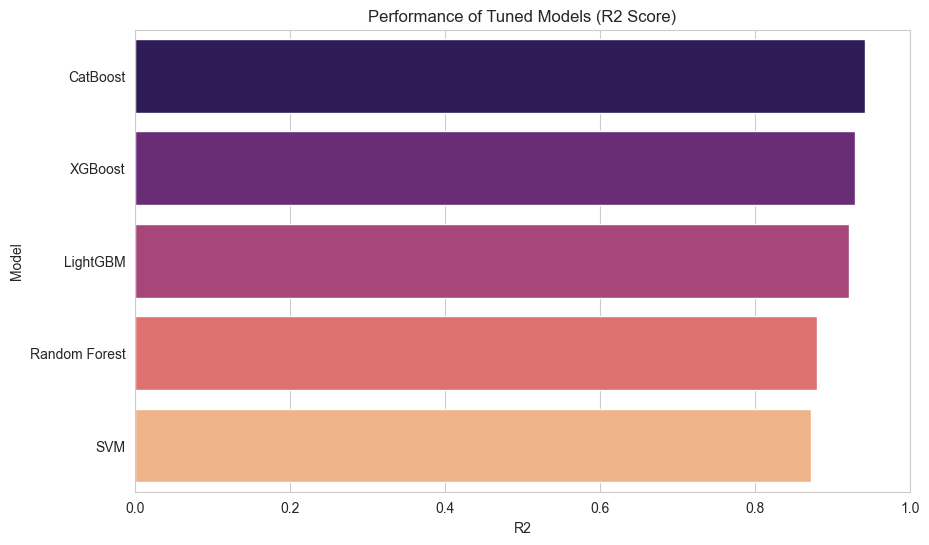


Saving Top 2 Models: CatBoost and XGBoost
Models saved successfully!


In [5]:
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import joblib

# 1. Load and Preprocess Data
df = pd.read_csv('Concrete_Data_Yeh.csv')
X = df.drop('csMPa', axis=1)
y = df['csMPa']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define Objective Functions for Optuna

def objective_rf(trial):
    # Random Forest Hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=3, scoring='r2').mean()
    return score

def objective_xgb(trial):
    # XGBoost Hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_jobs': -1,
        'random_state': 42
    }
    model = xgb.XGBRegressor(**params)
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=3, scoring='r2').mean()
    return score

def objective_lgb(trial):
    # LightGBM Hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'verbose': -1,
        'random_state': 42
    }
    model = lgb.LGBMRegressor(**params)
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=3, scoring='r2').mean()
    return score

def objective_cat(trial):
    # CatBoost Hyperparameters
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0),
        'verbose': 0,
        'random_state': 42
    }
    model = CatBoostRegressor(**params)
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=3, scoring='r2').mean()
    return score

def objective_svm(trial):
    # SVM Hyperparameters
    C = trial.suggest_float('C', 0.1, 100.0, log=True)
    epsilon = trial.suggest_float('epsilon', 0.01, 1.0)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    
    model = SVR(C=C, epsilon=epsilon, gamma=gamma)
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=3, scoring='r2').mean()
    return score

# 3. Run Optimization
studies = {}
# Dictionary mapping name to objective function
objectives = {
    "Random Forest": objective_rf,
    "XGBoost": objective_xgb,
    "LightGBM": objective_lgb,
    "CatBoost": objective_cat,
    "SVM": objective_svm
}

best_params = {}

print("Starting Optuna Optimization (This may take a few minutes)...")
for name, objective in objectives.items():
    print(f"\nOptimizing {name}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30) # Run 30 trials per model
    studies[name] = study
    best_params[name] = study.best_params
    print(f"Best R2 for {name}: {study.best_value:.4f}")

# 4. Train Final Models with Best Params
final_models = {}
results = []

print("\nTraining Final Models with Optimized Hyperparameters...")
for name, params in best_params.items():
    if name == "Random Forest":
        model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    elif name == "XGBoost":
        model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
    elif name == "CatBoost":
        model = CatBoostRegressor(**params, random_state=42, verbose=0)
    elif name == "SVM":
        model = SVR(**params)
        
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    final_models[name] = model
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse})

# 5. Visualization and Saving
results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print("\nFinal Tuned Model Performance:")
print(results_df)

# Plot Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='R2', y='Model', data=results_df, palette='magma')
plt.title('Performance of Tuned Models (R2 Score)')
plt.xlim(0, 1.0)
plt.show()

# Save Scaler and Top 2 Models
top_2 = results_df.head(2)['Model'].values
print(f"\nSaving Top 2 Models: {top_2[0]} and {top_2[1]}")

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(final_models[top_2[0]], 'best_model_1.pkl')
joblib.dump(final_models[top_2[1]], 'best_model_2.pkl')

print("Models saved successfully!")